# 1. LSTM
LSTM(Long Short-Term Memory)은 RNN의 장기 의존성 문제를 해결하기 위해 고안된 모델입니다. 

LSTM은 셀 상태(cell state)와 3개의 게이트(입력 게이트, 출력 게이트, 망각 게이트)를 사용하여 중요한 정보를 오랫동안 저장하고 불필요한 정보를 제거하는 구조를 갖추고 있습니다. 

망각 게이트는 이전 셀 상태에서 필요 없는 정보를 삭제하고, 입력 게이트는 새로운 정보를 저장하며, 출력 게이트는 최종 출력을 결정합니다. 

이러한 구조 덕분에 LSTM은 장기 시퀀스를 다루는 자연어 처리, 음성 인식, 시계열 예측 등의 다양한 분야에서 효과적으로 사용됩니다. 

하지만 구조가 복잡하여 계산량이 많고, 학습 시간이 오래 걸린다는 단점이 있습니다.


- 학습할 때는 마지막 오차를 과거 시점까지 거꾸로 전달

```
0.5

0.5 * 0.5 = 0.25

0.5 * 0.5 * 0.5 = 0.125

0.5^20 = ?
```

- 멀리 갈수록 Gradient가 매우 작아짐. 그러면 오래전 입력이 현재 오차에 어떤 영향을 주었는지 가중치가 거의 학습하지 못함 > 기울기 소실
- 1보다 큰 값이 반복적으로 곱해지면 Gradient가 지나치게 커질 수 있음 > 기울기 폭주

> Gradient가 정확히 0이어야만 기울기 소실은 아님. 0에 매우 가까워져 학습에 실질적인 영향을 거의 주지 못하는 상태도 기울기 소실이라고 함


1. Forget Gate
- 과거 기억을 남김
- sigmoid 결과로 단순한 삭제/유지가 아니라 이전 Cell State의 각 성분을 다음 단계로 얼마나 전달할지를 나타내는 0~1사이의 비율

2. Input Gate
- 새 정보를 얼마나 저장할지
- 새로운 후보 기억도 만듦

3. Output Gate
- 출력으로 무엇을 보여줄지
```
    이전 Cell State > Forget Gate
                                    > 원소별 곱 > 새로운 Cell State(c_t) > Output Gate > Hidden State(h_t)
    현재 입력 > Input Gate
```

> Cell State의 갱신(과거 기억 + 새 기억)은 과거 기억 중 남길 부분에서 현재 입력에서 새로 저장할 부분을 더한 값

### 장기/단기 기억을 나누는 기준

```
최근 24시간 전력 사용량

현재 시점 t
    - 1시간 전 값
    - 2시간 전 값
    - 3시간 전 값
    - ...
    - 24시간 전 값
```
- LSTM 내부에 6시간보다 오래되면 장기 정보, 3시간 이내면 단기 정보와 같은 규칙은 없음
- 얼마나 오래된 정보인가보다 그 정보가 예측에 얼마나 도움이 되었는가가 중요
- 예) 전력 데이터에서 "매일 저녁 비슷한 시간에 사용량이 증가" 패턴이 반복된다면, 비교적 이전 시점에서 만들어진 정보라도 다음 값을 예측하는 데 유용할 수 있음 > 장기정보
- 예) 1시간 전 정보라도 잡음에 가까워 예측에 도움이 되지 않는 성분은 > 단기정보

> 사람이 장기/단기 정보를 미리 지정하는 모델이 아니라 학습을 통해 어떤 과거 정보의 영향력을 계속 유지하고, 어떤 정보의 영향력을 줄일지를 결정

# **2. Household Electric Power Consumption 예제**
- 한 가정의 전력 사용량을 약 4년 동안 1분 간격으로 측정한 공개 시계열 데이터(약 207만 개의 관측치)
- Global_active_power 한 개만 이용해 최근 24시간의 전력 사용량 > 다음 1시간의 전력 사용량을 예측
  - 원본: 1분 간격 > 예제: 1시간 단위 평균으로 변환
  - 입력 X: 직전 24시간의 Global Active Power
  - 정답 y: 그 다음 1시간의 Global Active Power

In [2]:
import random
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

warnings.filterwarnings("ignore")

In [3]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.xpu.is_available():
    DEVICE = torch.device('xpu')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cuda


In [4]:
DATA_PATH = "./data/household_power_consumption.txt"
df = pd.read_csv(DATA_PATH, sep=";", na_values="?", low_memory=False)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
df.isna().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [6]:
df['datetime'] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%d/%m/%Y %H:%M:%S", errors="coerce")
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   str           
 1   Time                   str           
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   datetime               datetime64[us]
dtypes: datetime64[us](1), float64(7), str(2)
memory usage: 191.9 MB


In [8]:
df = df.sort_values("datetime")
df = df.set_index("datetime")
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [10]:
power = df[["Global_active_power"]].copy()
power["Global_active_power"] = pd.to_numeric(power["Global_active_power"], errors="coerce")
power = power.dropna()
print(power.shape)

(2049280, 1)


In [11]:
hourly = power.resample("1h").mean()
hourly

,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467
...,...
2010-11-26 17:00:00,1.725900
2010-11-26 18:00:00,1.573467
2010-11-26 19:00:00,1.659333


In [12]:
missing_hours = hourly["Global_active_power"].isna().sum()
missing_hours

np.int64(421)

In [13]:
hourly = power.resample("1h").mean()
missing_hours = hourly["Global_active_power"].isna().sum()
print("시간 단위 결측 개수: ", missing_hours)

시간 단위 결측 개수:  421


In [14]:
# 시계열 간격을 1시간으로 유지하기 위해 과거의 마지막 관측값으로 채움
# 이전 데이터를 다음 결측치에 채움
hourly = hourly.ffill().dropna()
hourly.shape

(34589, 1)

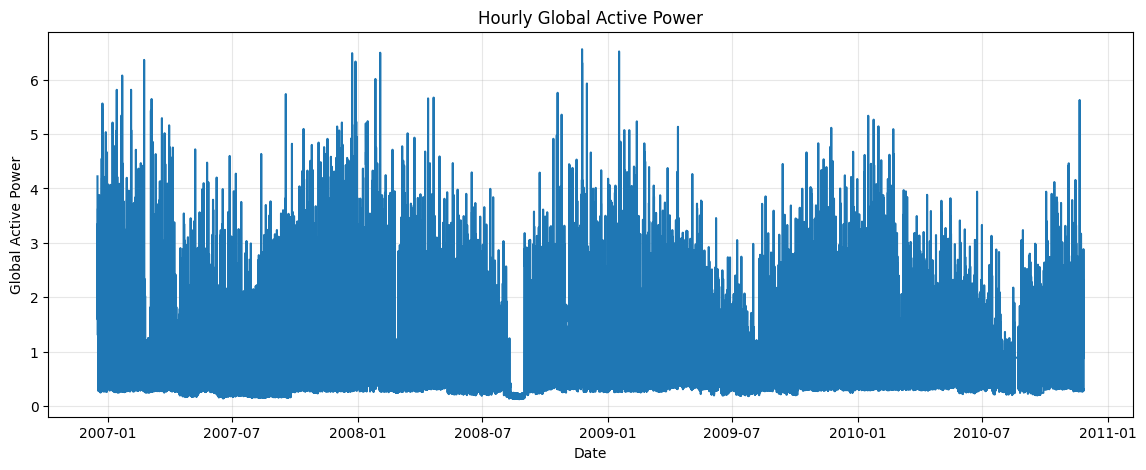

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(hourly.index, hourly["Global_active_power"])
plt.title("Hourly Global Active Power")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.grid(alpha=0.3)
plt.show()

In [16]:
n = len(hourly)

train_end = int(n * 0.70)
val_end = int(n * 0.85)
print("전체: ", n)
print("Train: ", train_end)
print("Val: ", val_end - train_end)
print("Test: ", n - val_end)

전체:  34589
Train:  24212
Val:  5188
Test:  5189


In [17]:
values = hourly[['Global_active_power']].to_numpy(dtype=np.float32); scaler = StandardScaler()

scaler.fit(values[:train_end])
scaled_values = scaler.transform(values).astype(np.float32)
scaled_values

array([[ 3.3853934 ],
       [ 2.748142  ],
       [ 2.4978902 ],
       ...,
       [ 0.61976004],
       [ 0.08505732],
       [-0.16203001]], shape=(34589, 1), dtype=float32)

In [18]:
SEQ_LENGTH = 24

def make_sequence(data, seq_length):
    X = []
    y = []
    target_indeces = []
    
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i]) # i-24 ~ i-1
        y.append(data[i]) # i 시점(바로 다음 1시간)
        target_indeces.append(i)

    return (np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(target_indeces))

In [ ]:
X, y, indices = make_sequence(scaled_values, SEQ_LENGTH)
print(X.shape)
print(y.shape)

print("첫 번째 X가 사용하는 원본 시간:", hourly.index[0], "~", hourly.index[SEQ_LENGTH-1])
print("")

(34565, 24, 1)
(34565, 1)


In [20]:
train_mask = indices < train_end
val_mask = (indices >= train_end) & (indices < val_end)
test_mask = indices >= val_end

print("Train sequences:", train_mask.sum())
print("Val sequences:", val_mask.sum())
print("Test sequences:", test_mask.sum())

X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print('Train: ', X_train.shape, y_train.shape)
print('Val: ', X_val.shape, y_val.shape)
print('Test: ', X_test.shape, y_test.shape)

Train sequences: 24188
Val sequences: 5188
Test sequences: 5189
Train:  (24188, 24, 1) (24188, 1)
Val:  (5188, 24, 1) (5188, 1)
Test:  (5189, 24, 1) (5189, 1)


In [21]:
class PowerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [23]:
BATCH_SIZE=64

train_loader = DataLoader(PowerDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(PowerDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(PowerDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

In [24]:
xb, yb = next(iter(train_loader))

xb.shape, yb.shape

(torch.Size([64, 24, 1]), torch.Size([64, 1]))

### LSTM의 입력과 출력
- batch_first=True일 때 입력 x의 shape는 (batch_size, sequence_length, input_size)
- 예) (64, 24, 1): batch에 64개 sequence, 직전 24시간, 한 시간마다 feature 1개
- LSTM을 통과시키면 out, (h_n, c_n) = self.lstm(x)
    - out: 모든 시점의 마지막 LSTM layer hidden state > (batch, seq_len, hidden_size)
    - h_n: 각 layer의 마지막 시점 hidden state > (num_layers, batch, hidden_size)
    - c_n: 각 layer의 마지막 시점 Cell state > (num_layers, batch, hidden_size)

> 단방향 LSTM에서 마지막 layer에 대해 마지막 hidden state는 out[:, -1, :]와 h_n[-1]

In [26]:
class PowerLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = out[:, -1, :]
        prediction = self.fc(last_hidden)
        return prediction

In [27]:
model = PowerLSTM().to(DEVICE)
model

PowerLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [30]:
model.eval()

with torch.no_grad():
  sample_x = xb[:4].to(DEVICE)
  out, (h_n, c_n) = model.lstm(sample_x)

print("입력:", sample_x.shape)
print("out:", out.shape)
print("h_n:", h_n.shape)
print("c_n:", c_n.shape)

입력: torch.Size([4, 24, 1])
out: torch.Size([4, 24, 64])
h_n: torch.Size([2, 4, 64])
c_n: torch.Size([2, 4, 64])


In [36]:
sum([p.numel() for p in model.lstm.parameters()]), sum([p.numel() for p in model.fc.parameters()])

(50432, 65)

In [52]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

MAX_EPOCHS = 50
PATIENCE = 8
CLIP_NORM = 1.0

In [37]:
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_count = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)

            batch_size = xb.size(0)
            total_loss += loss.item() * batch_size
            total_count += batch_size

    return total_loss / total_count

In [38]:
best_val_loss = float("inf")
best_state = None
wait = 0

train_history = []
val_history = []

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    train_count = 0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP_NORM)
        optimizer.step()

        
        batch_size = xb.size(0)
        train_loss_sum += (loss.item() * batch_size)
        train_count += batch_size

    train_loss = (train_loss_sum / train_count)
    val_loss = evaluate_loss(model, val_loader, criterion, DEVICE)
    train_history.append(train_loss)
    val_history.append(val_loss)


    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1

    print(
        f"Epoch {epoch:02d} | "
        f"Train {train_loss:.6f} | "
        f"Valid {val_loss:.6f}"
    )

    if wait >= PATIENCE:
        print("Early Stopping")
        break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01 | Train 0.536548 | Valid 0.413444
Epoch 02 | Train 0.429974 | Valid 0.395547
Epoch 03 | Train 0.418928 | Valid 0.386642
Epoch 04 | Train 0.418372 | Valid 0.384643
Epoch 05 | Train 0.413259 | Valid 0.384440
Epoch 06 | Train 0.409494 | Valid 0.379045
Epoch 07 | Train 0.408871 | Valid 0.382011
Epoch 08 | Train 0.407495 | Valid 0.381821
Epoch 09 | Train 0.405779 | Valid 0.378070
Epoch 10 | Train 0.403624 | Valid 0.373204
Epoch 11 | Train 0.402597 | Valid 0.380654
Epoch 12 | Train 0.400761 | Valid 0.383954
Epoch 13 | Train 0.398179 | Valid 0.382551
Epoch 14 | Train 0.399173 | Valid 0.378842
Epoch 15 | Train 0.397600 | Valid 0.373191
Epoch 16 | Train 0.396110 | Valid 0.377745
Epoch 17 | Train 0.394272 | Valid 0.378913
Epoch 18 | Train 0.394641 | Valid 0.371239
Epoch 19 | Train 0.392533 | Valid 0.370772
Epoch 20 | Train 0.390684 | Valid 0.377678
Epoch 21 | Train 0.388593 | Valid 0.368581
Epoch 22 | Train 0.388087 | Valid 0.375942
Epoch 23 | Train 0.386098 | Valid 0.373241
Epoch 24 | 

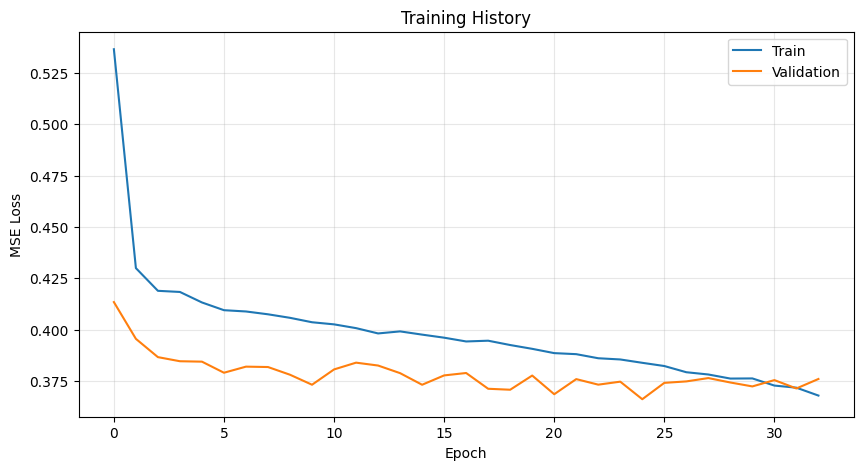

In [39]:
plt.figure(figsize=(10, 5))
plt.plot(train_history, label="Train")
plt.plot(val_history, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [41]:
def predict(model, loader, device):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            preds.append(pred.cpu().numpy())
            trues.append(yb.cpu().numpy())
    return (np.vstack(preds), np.vstack(trues))

In [42]:
pred_scaled, true_scaled = predict(model, test_loader, DEVICE)
pred = scaler.inverse_transform(pred_scaled).ravel()
true = scaler.inverse_transform(true_scaled).ravel()

In [44]:
rmse = root_mean_squared_error(true, pred)
mae = mean_absolute_error(true, pred)
print(f"LSTM RMSE: {rmse:.4f}")
print(f"LSTM MAE : {mae:.4f}")

LSTM RMSE: 0.4873
LSTM MAE : 0.3346


In [47]:
last_input_scaled = X_test[:, -1, :]
baseline_pred = scaler.inverse_transform(last_input_scaled).ravel()

baseline_rmse = root_mean_squared_error(true, baseline_pred)
baseline_mae = mean_absolute_error(true, baseline_pred)

print(f"Persistence RMSE: {baseline_rmse:.4f}")
print(f"Persistence MAE: {baseline_mae:.4f}")
print(f"LSTM RMSE: {rmse:.4f}")
print(f"LSTM MAE : {mae:.4f}")

Persistence RMSE: 0.5759
Persistence MAE: 0.3729
LSTM RMSE: 0.4873
LSTM MAE : 0.3346


In [48]:
test_indices = indices[test_mask]
test_dates = hourly.index[test_indices]
N_VIEW = min(200, len(test_dates))

In [49]:
len(test_dates)

5189

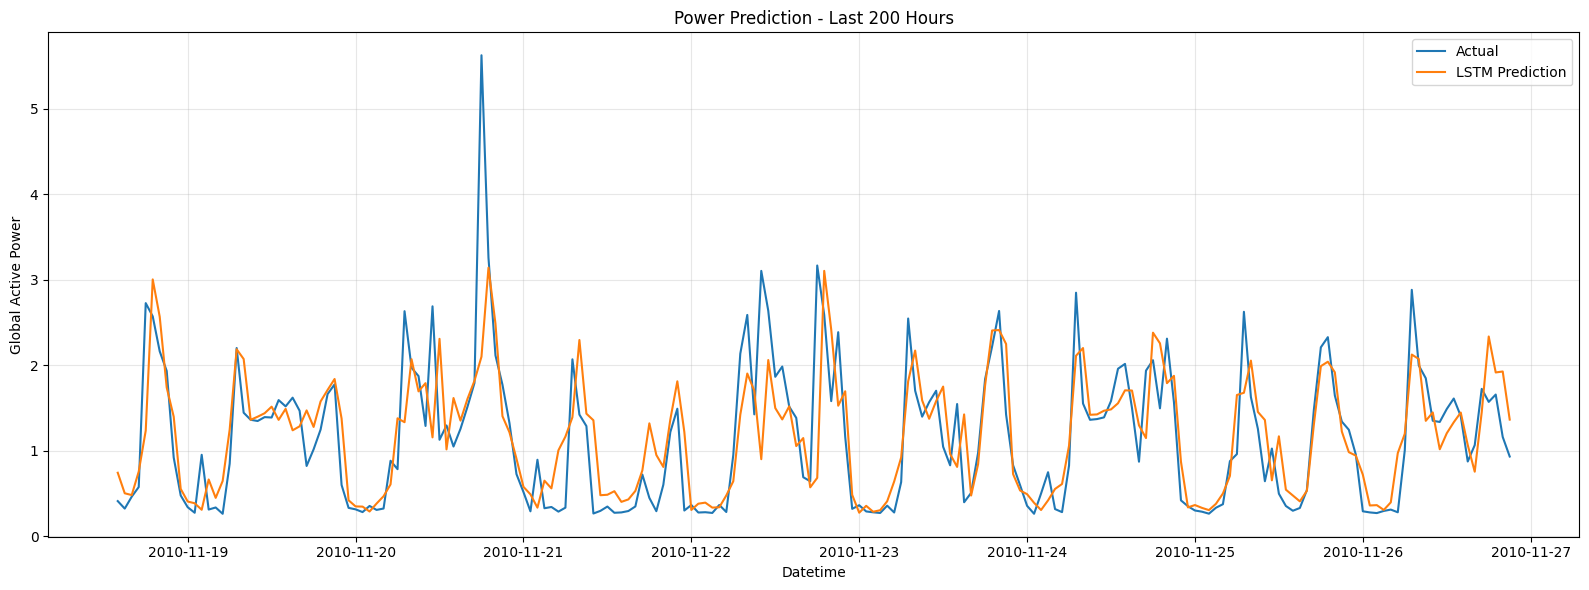

In [50]:
plt.figure(figsize=(16, 6))

plt.plot(
    test_dates[-N_VIEW:],
    true[-N_VIEW:],
    label="Actual"
)

plt.plot(
    test_dates[-N_VIEW:],
    pred[-N_VIEW:],
    label="LSTM Prediction"
)

plt.title(
    f"Power Prediction - Last {N_VIEW} Hours"
)

plt.xlabel("Datetime")
plt.ylabel("Global Active Power")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
class RNNRegressor(nn.Module):
  def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.10):
    super().__init__()
    self.rnn = nn.RNN(
      input_size=input_size,
      hidden_size=hidden_size,
      num_layers=num_layers,
      nonlinearity="tanh",
      batch_first=True,
      dropout=dropout if num_layers > 1 else 0.0
    )
    self.fc = nn.Linear(hidden_size, 1)

  def forward(self, x):
    # out: 모든 time step의 마지막 RNN Layer을 출력하게 됨.
    # h_n: rnn layer의 마지막 hidden state
    out, h_n = self.rnn(x)

    # out.shape: [batch, sequence_length, hidden_size]
    last_hidden = out[:, -1, :]
    pred = self.fc(last_hidden)
    
    return pred

In [53]:
model = RNNRegressor(
  input_size=1,
  hidden_size=64,
  num_layers=2,
  dropout=0.1
).to(DEVICE)

In [54]:
# HuberLoss: 회귀 문제에서 MSE와 MAE의 장점을 섞음. 오차가 작으면 제곱처럼 계산하고, 오차가 크면 선형적으로 계산
criterion = nn.HuberLoss(delta=1.0) # delta: 관계선
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

MAX_EPOCHS = 200
PATIENCE = 15
# 기울기 폭발 방지
CLIP_NORM = 1.0

In [55]:
best_val_loss = float("inf")
best_state = None
wait = 0

train_history = []
val_history = []

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    train_count = 0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP_NORM)
        optimizer.step()

        
        batch_size = xb.size(0)
        train_loss_sum += (loss.item() * batch_size)
        train_count += batch_size

    train_loss = (train_loss_sum / train_count)
    val_loss = evaluate_loss(model, val_loader, criterion, DEVICE)
    train_history.append(train_loss)
    val_history.append(val_loss)


    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1

    print(
        f"Epoch {epoch:02d} | "
        f"Train {train_loss:.6f} | "
        f"Valid {val_loss:.6f}"
    )

    if wait >= PATIENCE:
        print("Early Stopping")
        break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01 | Train 0.202535 | Valid 0.187631
Epoch 02 | Train 0.188157 | Valid 0.184936
Epoch 03 | Train 0.187081 | Valid 0.181510
Epoch 04 | Train 0.186332 | Valid 0.180540
Epoch 05 | Train 0.183257 | Valid 0.174775
Epoch 06 | Train 0.183471 | Valid 0.187800
Epoch 07 | Train 0.182325 | Valid 0.179346
Epoch 08 | Train 0.180671 | Valid 0.175678
Epoch 09 | Train 0.180644 | Valid 0.179189
Epoch 10 | Train 0.179783 | Valid 0.175611
Epoch 11 | Train 0.180534 | Valid 0.174633
Epoch 12 | Train 0.179671 | Valid 0.172298
Epoch 13 | Train 0.178656 | Valid 0.173945
Epoch 14 | Train 0.178897 | Valid 0.174451
Epoch 15 | Train 0.178385 | Valid 0.172867
Epoch 16 | Train 0.177070 | Valid 0.175597
Epoch 17 | Train 0.176741 | Valid 0.174781
Epoch 18 | Train 0.176163 | Valid 0.172790
Epoch 19 | Train 0.175856 | Valid 0.172053
Epoch 20 | Train 0.176518 | Valid 0.176367
Epoch 21 | Train 0.175342 | Valid 0.174800
Epoch 22 | Train 0.173810 | Valid 0.169681
Epoch 23 | Train 0.174061 | Valid 0.169710
Epoch 24 | 

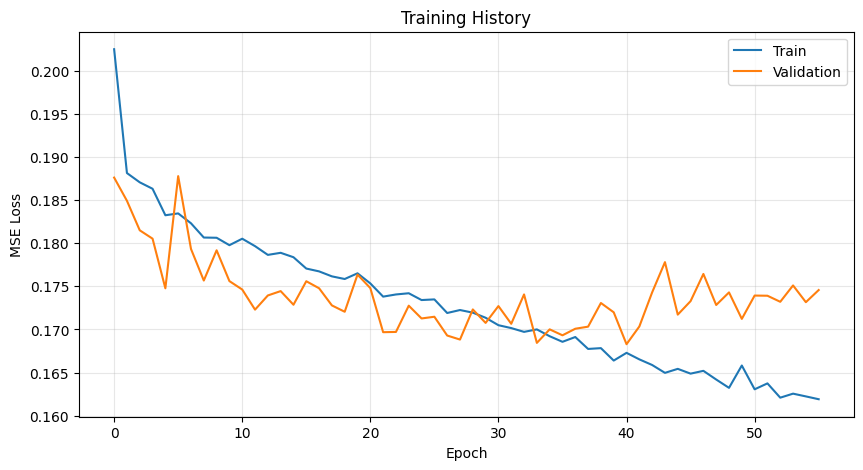

In [56]:
plt.figure(figsize=(10, 5))
plt.plot(train_history, label="Train")
plt.plot(val_history, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [57]:
pred_scaled, true_scaled = predict(model, test_loader, DEVICE)
pred = scaler.inverse_transform(pred_scaled).ravel()
true = scaler.inverse_transform(true_scaled).ravel()

In [58]:
rnn_rmse = root_mean_squared_error(true, pred)
rnn_mae = mean_absolute_error(true, pred)
print(f"RNN RMSE: {rnn_rmse:.4f}")
print(f"RNN MAE : {rnn_mae:.4f}")
print(f"LSTM RMSE: {rmse:.4f}")
print(f"LSTM MAE : {mae:.4f}")

RNN RMSE: 0.4945
RNN MAE : 0.3375
LSTM RMSE: 0.4873
LSTM MAE : 0.3346


In [59]:
last_input_scaled = X_test[:, -1, :]
baseline_pred = scaler.inverse_transform(last_input_scaled).ravel()

baseline_rmse = root_mean_squared_error(true, baseline_pred)
baseline_mae = mean_absolute_error(true, baseline_pred)

print(f"Persistence RMSE: {baseline_rmse:.4f}")
print(f"Persistence MAE: {baseline_mae:.4f}")
print(f"RNN RMSE: {rnn_rmse:.4f}")
print(f"RNN MAE : {rnn_mae:.4f}")
print(f"LSTM RMSE: {rmse:.4f}")
print(f"LSTM MAE : {mae:.4f}")

Persistence RMSE: 0.5759
Persistence MAE: 0.3729
RNN RMSE: 0.4945
RNN MAE : 0.3375
LSTM RMSE: 0.4873
LSTM MAE : 0.3346


# 2. GRU
GRU(Gated Recurrent Unit)는 2014년 뉴욕대학교(NYU) 조경현(Kyunghyun Cho) 교수 연구팀이 제안한 RNN의 장기 의존성 문제를 해결하기 위해 개발한 신경망 구조입니다. 

LSTM과 유사한 성능을 가지면서도 더 간단한 구조를 갖고 있어 연산량이 적고 학습 속도가 빠릅니다. 

GRU는 업데이트 게이트(Update Gate)와 리셋 게이트(Reset Gate)라는 두 개의 게이트만을 사용하여 정보를 조절하며, LSTM보다 파라미터 수가 적어 적은 데이터셋에서도 효과적으로 학습할 수 있습니다. 

업데이트 게이트는 이전 정보를 얼마나 유지할지 결정하고, 리셋 게이트는 새로운 정보를 반영하기 위해 기존 정보를 얼마나 잊을지 조정합니다. 

이러한 특성 덕분에 GRU는 텍스트 처리, 음성 인식, 시계열 예측 등에서 LSTM보다 더 빠르고 효율적으로 사용할 수 있지만, 장기 의존성이 중요한 경우 LSTM이 더 나은 성능을 보일 수도 있습니다.

![gru](./image.png)

모듈 생성 방식은 동일
```
LSTM
lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
out, (h_n, c_n) = lstm(x)

GRU
gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
out, h_n = gru(x)
```
GRU는 별도의 cell state가 없으므로 hidden state만 반환